In [1]:
# === Configuración de imports desde src/ (opción 2: __init__.py en src/) ===
import sys
import os
sys.path.append(os.path.abspath(".."))  # subir un nivel desde /notebooks

from src.feature_detection import detectar_y_describir
from src.matching import emparejar_y_filtrar
from src.registration import estimar_homografia
from src.stitching import unificar_dos_imagenes

from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

# === Directorios ===
DATA_DIR = Path("../data/original")   # imágenes reales (IMG01/02/03.jpg)
FIG_DIR  = Path("../results/figures") # salida de figuras/panorama
FIG_DIR.mkdir(parents=True, exist_ok=True)

# === Rutas de imágenes ===
IMG_A = DATA_DIR / "IMG01.jpg"  # base del mosaico (A)
IMG_B = DATA_DIR / "IMG02.jpg"  # segunda imagen (B)
IMG_C = DATA_DIR / "IMG03.jpg"  # tercera imagen (C)

for p in (IMG_A, IMG_B, IMG_C):
    if not p.exists():
        raise FileNotFoundError(f"No se encontró: {p.resolve()}")


Dimensiones A: (633, 475, 3) B: (633, 475, 3) C: (633, 844, 3)


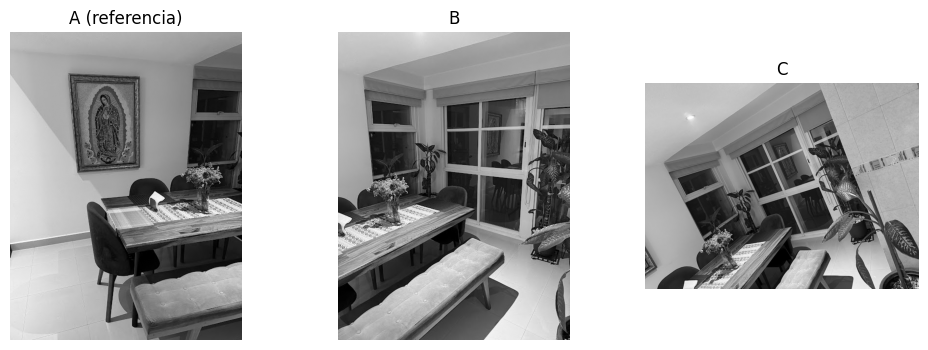

In [2]:
# Cargar imágenes en BGR (formato natural de OpenCV)
A_bgr = cv2.imread(str(IMG_A))
B_bgr = cv2.imread(str(IMG_B))
C_bgr = cv2.imread(str(IMG_C))

# Validar cargas
if A_bgr is None or B_bgr is None or C_bgr is None:
    raise RuntimeError("cv2.imread devolvió None. Revisa rutas/permiso/formato.")

# Convertir a escala de grises para detección de características (más eficiente)
A_g = cv2.cvtColor(A_bgr, cv2.COLOR_BGR2GRAY)
B_g = cv2.cvtColor(B_bgr, cv2.COLOR_BGR2GRAY)
C_g = cv2.cvtColor(C_bgr, cv2.COLOR_BGR2GRAY)

print("Dimensiones A:", A_bgr.shape, "B:", B_bgr.shape, "C:", C_bgr.shape)

# Previsualización rápida
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(A_g, cmap='gray')
plt.title("A (referencia)")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(B_g, cmap='gray')
plt.title("B")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(C_g, cmap='gray')
plt.title("C")
plt.axis('off')
plt.show()


In [3]:
def draw_matches(img1_bgr, kp1, img2_bgr, kp2, matches, max_draw=80, title="Matches"):
    """
    Dibuja correspondencias entre dos imágenes para inspección visual.
    Nota: convierte a RGB para mostrar con matplotlib.
    """
    sel = matches[:max_draw] if len(matches) > max_draw else matches
    vis = cv2.drawMatches(
        img1_bgr, kp1, img2_bgr, kp2, sel, None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
              | cv2.DrawMatchesFlags_DRAW_RICH_KEYPOINTS
    )
    plt.figure(figsize=(14,7))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()


Matches A<-B: 133
H_AB:
 [[ 4.80031695e-01 -3.70973872e-02  3.37818592e+02]
 [-2.20501631e-01  9.93975582e-01 -1.11409569e+01]
 [-1.19320446e-03  2.57737346e-04  1.00000000e+00]]
Métricas A<-B: {'num_matches': 133, 'num_inliers': 115, 'inlier_ratio': 0.8646616541353384}
Inliers A<-B: 115


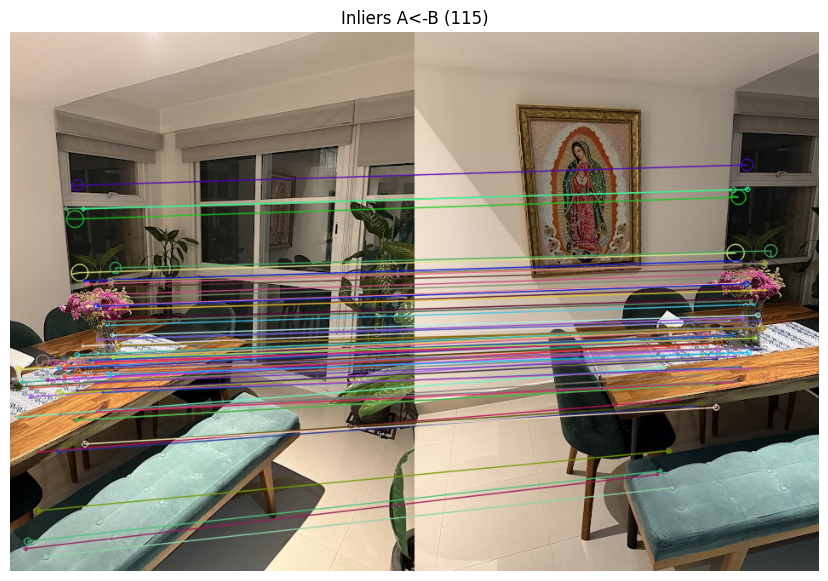

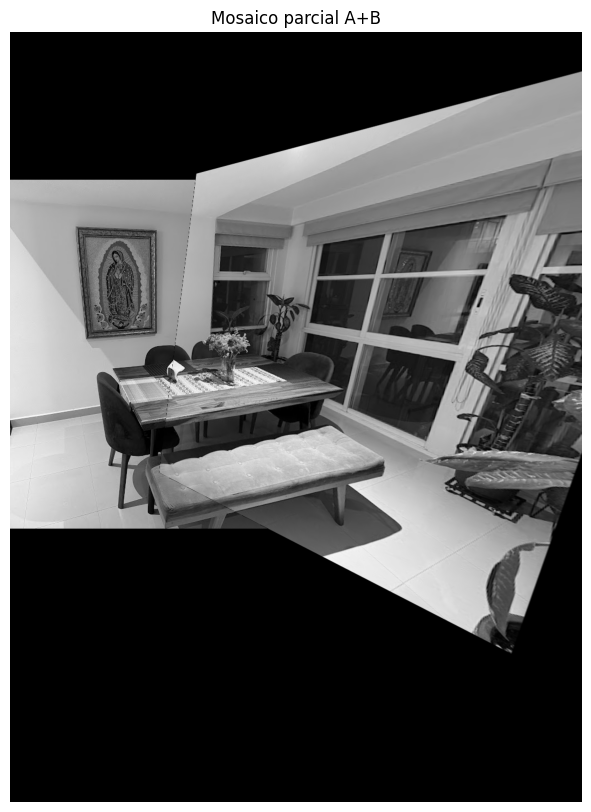

In [4]:
# Parámetros del pipeline (puedes experimentar)
DETECTOR = "SIFT"  # Cambiar a "ORB" si no tienes opencv-contrib
RATIO    = 0.75    # Umbral de Lowe
RANSAC_T = 5.0     # Umbral de reproyección para RANSAC (px)

# 1) Detección + descripción
kpA, desA = detectar_y_describir(A_g, DETECTOR)
kpB, desB = detectar_y_describir(B_g, DETECTOR)
if desA is None or desB is None:
    raise RuntimeError("Descriptores None. Prueba ORB o revisa imágenes.")

# 2) Emparejamiento filtrado (desB -> desA)
mAB = emparejar_y_filtrar(desB, desA, DETECTOR, ratio_umbral=RATIO)
print("Matches A<-B:", len(mAB))
if len(mAB) < 4:
    raise RuntimeError("Muy pocos matches A<-B. Ajusta RATIO o cambia de detector.")

# 3) Estimación de homografía con RANSAC y métrica de inliers
H_AB, inAB, metAB = estimar_homografia(kpB, kpA, mAB, ransac_thresh=RANSAC_T)
print("H_AB:\n", H_AB)
print("Métricas A<-B:", metAB)

# 4) Visualización de INLIERS para control de calidad
if inAB is not None:
    inlier_matches_AB = [m for m, flag in zip(mAB, inAB.ravel().astype(bool)) if flag]
    print("Inliers A<-B:", len(inlier_matches_AB))
    draw_matches(B_bgr, kpB, A_bgr, kpA, inlier_matches_AB, title=f"Inliers A<-B ({len(inlier_matches_AB)})")

# 5) Unificación parcial (mosaico A+B)
mosaico_AB = unificar_dos_imagenes(A_bgr, B_bgr, H_AB)
plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(mosaico_AB, cv2.COLOR_BGR2RGB))
plt.title("Mosaico parcial A+B")
plt.axis('off')
plt.show()


Matches (A+B)<-C: 200
H_C_AB:
 [[ 2.99121706e-01 -1.44914293e-01  4.17248090e+02]
 [-9.68569714e-02  9.60490596e-01  1.49985127e+02]
 [-9.16115093e-04  5.34724534e-04  1.00000000e+00]]
Métricas (A+B)<-C: {'num_matches': 200, 'num_inliers': 121, 'inlier_ratio': 0.605}
Inliers (A+B)<-C: 121


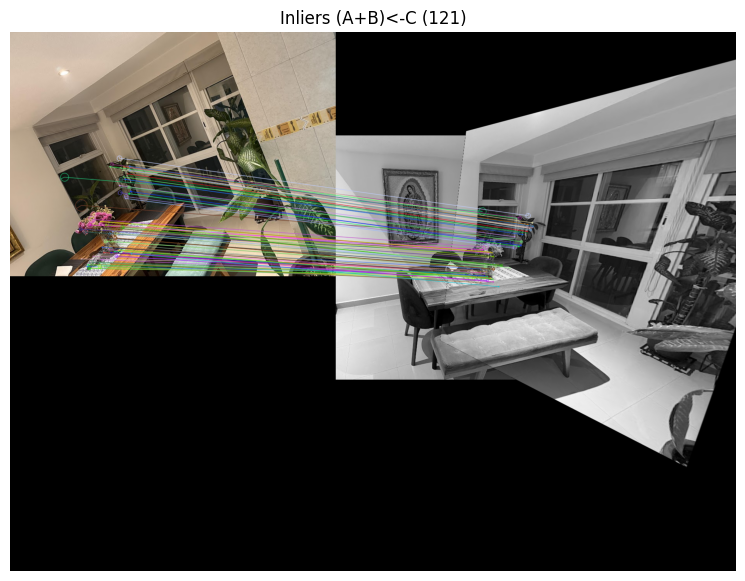

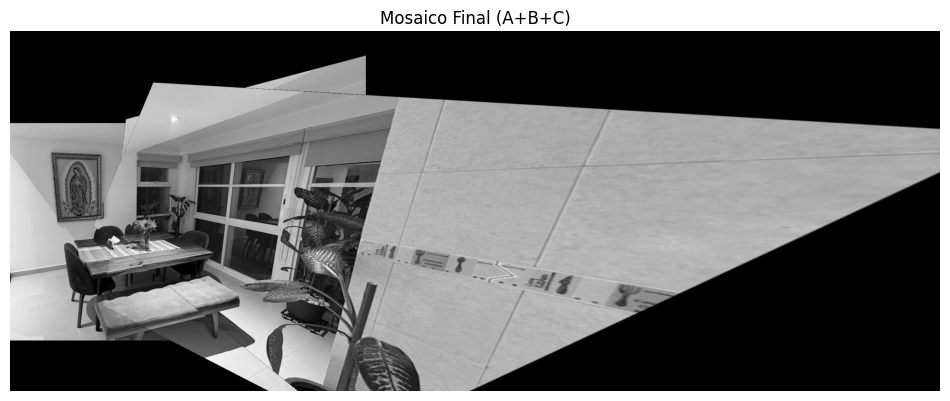

Panorama guardado en: /home/david/Documents/Trabajo 2/results/figures/panorama.png
Tamaño panorama: (1048, 2710, 3)


In [5]:
# 1) Detección en mosaico_AB y C
mAB_g = cv2.cvtColor(mosaico_AB, cv2.COLOR_BGR2GRAY)
kpAB, desAB = detectar_y_describir(mAB_g, DETECTOR)
kpC,  desC  = detectar_y_describir(C_g,  DETECTOR)

if desAB is None or desC is None:
    raise RuntimeError("Descriptores None en mosaico o C.")

# 2) Emparejamiento (desC -> desAB)
mCAB = emparejar_y_filtrar(desC, desAB, DETECTOR, ratio_umbral=RATIO)
print("Matches (A+B)<-C:", len(mCAB))
if len(mCAB) < 4:
    raise RuntimeError("Muy pocos matches (A+B)<-C.")

# 3) Estimación de homografía
H_C_AB, inC, metC = estimar_homografia(kpC, kpAB, mCAB, ransac_thresh=RANSAC_T)
print("H_C_AB:\n", H_C_AB)
print("Métricas (A+B)<-C:", metC)

# 4) Visualización de inliers
if inC is not None:
    inlier_matches_C = [m for m, flag in zip(mCAB, inC.ravel().astype(bool)) if flag]
    print("Inliers (A+B)<-C:", len(inlier_matches_C))
    draw_matches(C_bgr, kpC, mosaico_AB, kpAB, inlier_matches_C, title=f"Inliers (A+B)<-C ({len(inlier_matches_C)})")

# 5) Panorama final (A+B+C)
panorama_bgr = unificar_dos_imagenes(mosaico_AB, C_bgr, H_C_AB)

plt.figure(figsize=(12,10))
plt.imshow(cv2.cvtColor(panorama_bgr, cv2.COLOR_BGR2RGB))
plt.title("Mosaico Final (A+B+C)")
plt.axis('off')
plt.show()

# 6) Guardar panorama
out_panorama = FIG_DIR / "panorama.png"
cv2.imwrite(str(out_panorama), cv2.cvtColor(panorama_bgr, cv2.COLOR_BGR2RGB))
print("Panorama guardado en:", out_panorama.resolve())
print("Tamaño panorama:", panorama_bgr.shape)
